In [8]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 130

PROJECT_ROOT = Path("/Users/dannyyy/Downloads/accessops_coco_ai")
ART = PROJECT_ROOT / "artifacts"

ABL = ART / "stage8_ablation"
FIG = ABL / "figures"
TAB = ABL / "tables"
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)

PATHS = {
    "stage3_metrics": ART / "stage3" / "metrics.json",
    "stage4_metrics": ART / "stage4" / "metrics.json",
    "stage4d_metrics": ART / "stage4d_attention" / "metrics.json",
    "stage5_train": ART / "stage5" / "stage4b_results_final.csv",
    "stage5_decode": ART / "stage5" / "stage5_decode_results_fast.csv",
    "stage6_rl": ART / "stage6" / "rl_metrics.json",
    "stage6_reroute": ART / "stage6" / "reroute_threshold_sweep.csv",
    "stage7_metrics": ART / "stage7" / "metrics.json",
    "stage7_tune": ART / "stage7" / "rag_threshold_sweep.csv",
}

for k, p in PATHS.items():
    assert p.exists(), f"Missing {k}: {p}"

print("Stage 8 setup OK")
print("Output dir:", ABL)


Stage 8 setup OK
Output dir: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/stage8_ablation


In [9]:
def read_json(p: Path):
    return json.loads(p.read_text(encoding="utf-8"))

m3 = read_json(PATHS["stage3_metrics"])
m4 = read_json(PATHS["stage4_metrics"])
m4d = read_json(PATHS["stage4d_metrics"])
m6 = read_json(PATHS["stage6_rl"])
m7 = read_json(PATHS["stage7_metrics"])

b2_df = pd.read_csv(PATHS["stage5_train"])
decode_df = pd.read_csv(PATHS["stage5_decode"])
reroute_df = pd.read_csv(PATHS["stage6_reroute"])
rag_tune_df = pd.read_csv(PATHS["stage7_tune"])

for c in ["lr", "epochs", "val_loss_best", "bleu1_fast", "bleu4_fast", "bleu1_full", "bleu4_full"]:
    if c in b2_df.columns:
        b2_df[c] = pd.to_numeric(b2_df[c], errors="coerce")

for c in ["beam_size", "length_penalty", "bleu1_fast", "bleu4_fast"]:
    if c in decode_df.columns:
        decode_df[c] = pd.to_numeric(decode_df[c], errors="coerce")

for c in ["threshold", "auto_rate", "human_reroute_rate", "auto_bleu4", "overall_bleu4_generated"]:
    if c in reroute_df.columns:
        reroute_df[c] = pd.to_numeric(reroute_df[c], errors="coerce")

for c in ["sim_thresh", "conf_thresh", "replace_rate_tune", "bleu1_tune", "bleu4_tune", "n_eval_tune"]:
    if c in rag_tune_df.columns:
        rag_tune_df[c] = pd.to_numeric(rag_tune_df[c], errors="coerce")

# Rank Stage 5 training runs (prefer full if available, fallback fast)
b2_df["bleu1_rank"] = b2_df["bleu1_fast"]
b2_df["bleu4_rank"] = b2_df["bleu4_fast"]
best_b2 = b2_df.sort_values(["bleu4_rank", "bleu1_rank"], ascending=[False, False]).iloc[0]

best_decode = decode_df.sort_values(["bleu4_fast", "bleu1_fast"], ascending=[False, False]).iloc[0]
best_rag_tune = rag_tune_df.sort_values(["bleu4_tune", "bleu1_tune"], ascending=[False, False]).iloc[0]
best_reroute_auto = reroute_df.sort_values(["auto_bleu4", "auto_rate"], ascending=[False, True]).iloc[0]
reroute_50 = reroute_df.iloc[(reroute_df["auto_rate"] - 0.5).abs().argsort()[:1]].iloc[0]

print("Best Stage5 train run:", best_b2["run_id"])
print("Best Stage5 decode run:", best_decode["run_id"])
print("Best Stage7 tune (BLEU-4):", dict(best_rag_tune))


Best Stage5 train run: B2_adamw_5e5
Best Stage5 decode run: B1_beam3_lp06
Best Stage7 tune (BLEU-4): {'sim_thresh': 0.6, 'conf_thresh': 0.4, 'replace_rate_tune': 0.068, 'bleu1_tune': 0.6676562588702529, 'bleu4_tune': 0.2246803662453734, 'n_eval_tune': 500.0}


In [10]:
full_rag = m7["full_scores"]

rows = [
    {"variant": "Stage3_Scratch", "type": "architecture", "bleu1": m3.get("test_bleu1"), "bleu4": m3.get("test_bleu4"), "note": "CNN+LSTM scratch"},
    {"variant": "Stage4_Transfer", "type": "architecture", "bleu1": m4.get("test_bleu1"), "bleu4": m4.get("test_bleu4"), "note": "transfer baseline"},
    {"variant": "Stage4D_Attention", "type": "architecture", "bleu1": m4d.get("test_bleu1"), "bleu4": m4d.get("test_bleu4"), "note": "attention ablation"},
    {"variant": "Stage5_BestTrain", "type": "optimizer/lr", "bleu1": float(best_b2["bleu1_rank"]), "bleu4": float(best_b2["bleu4_rank"]), "note": str(best_b2["run_id"])},
    {"variant": "Stage5_BestDecode", "type": "decoding", "bleu1": float(best_decode["bleu1_fast"]), "bleu4": float(best_decode["bleu4_fast"]), "note": f"{best_decode['run_id']}"},
    {"variant": "Stage6_RL", "type": "rl", "bleu1": m6.get("bleu1_full"), "bleu4": m6.get("bleu4_full"), "note": "SCST"},
    {"variant": "Stage7_RAG", "type": "rag", "bleu1": full_rag.get("rag_bleu1"), "bleu4": full_rag.get("rag_bleu4"), "note": "retrieval refinement"},
]

ablation_df = pd.DataFrame(rows)
stage4_bleu4 = float(m4.get("test_bleu4", np.nan))
ablation_df["delta_bleu4_vs_stage4"] = ablation_df["bleu4"] - stage4_bleu4
ablation_df = ablation_df.sort_values("bleu4", ascending=False).reset_index(drop=True)

ablation_path = TAB / "ablation_master_table.csv"
ablation_df.to_csv(ablation_path, index=False)

display(ablation_df)
print("Saved:", ablation_path)


,variant,type,bleu1,bleu4,note,delta_bleu4_vs_stage4
0,Stage5_BestDecode,decoding,0.667942,0.247279,B1_beam3_lp06,0.027970
1,Stage5_BestTrain,optimizer/lr,0.670782,0.230983,B2_adamw_5e5,0.011673
2,Stage6_RL,rl,0.670666,0.222123,SCST,0.002813
3,Stage7_RAG,rag,0.669781,0.221124,retrieval refinement,0.001814
4,Stage4_Transfer,architecture,0.669339,0.219309,transfer baseline,0.000000
5,Stage3_Scratch,architecture,0.598141,0.168521,CNN+LSTM scratch,-0.050788
6,Stage4D_Attention,architecture,0.000524,0.000098,attention ablation,-0.219211


Saved: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/stage8_ablation/tables/ablation_master_table.csv


In [11]:
train_ablation = b2_df[[
    "run_id", "optimizer", "lr", "epochs", "val_loss_best", "bleu1_rank", "bleu4_rank", "notes"
]].sort_values(["bleu4_rank", "bleu1_rank"], ascending=[False, False])

decode_ablation = decode_df.sort_values(["bleu4_fast", "bleu1_fast"], ascending=[False, False])

reroute_ablation = reroute_df.sort_values(["auto_bleu4", "auto_rate"], ascending=[False, True])

rag_ablation = rag_tune_df.sort_values(["bleu4_tune", "bleu1_tune"], ascending=[False, False])

train_ablation.to_csv(TAB / "train_optimizer_ablation.csv", index=False)
decode_ablation.to_csv(TAB / "decode_ablation.csv", index=False)
reroute_ablation.to_csv(TAB / "reroute_ablation.csv", index=False)
rag_ablation.to_csv(TAB / "rag_tune_ablation.csv", index=False)

display(train_ablation.head(10))
display(decode_ablation.head(10))
display(reroute_ablation.head(10))
display(rag_ablation.head(10))

print("Saved component tables in:", TAB)


,run_id,optimizer,lr,epochs,val_loss_best,bleu1_rank,bleu4_rank,notes
3,B2_adamw_5e5,adamw,0.00005,3,2.421805,0.670782,0.230983,ckpt=B2_adamw_5e5.keras
1,B2_adam_1e4,adam,0.00010,3,2.437979,0.664631,0.225367,ckpt=B2_adam_1e4.keras
2,B2_adamw_8e5,adamw,0.00008,3,2.428496,0.666582,0.223830,ckpt=B2_adamw_8e5.keras
0,B0_baseline_stage4A_metrics,NaN,NaN,0,2.426270,0.669339,0.219309,Locked from stage4 metrics.json


,run_id,source_ckpt,strategy,beam_size,length_penalty,bleu1_fast,bleu4_fast
0,B1_beam3_lp06,B2_adamw_5e5,beam,3,0.6,0.667942,0.247279
1,B1_greedy,B2_adamw_5e5,greedy,1,0.0,0.670782,0.230983
2,B1_beam5_lp07,B2_adamw_5e5,beam,5,0.7,0.650813,0.227742
3,B1_beam5_lp09,B2_adamw_5e5,beam,5,0.9,0.646483,0.224148


,threshold,auto_rate,human_reroute_rate,auto_bleu4,overall_bleu4_generated
0,0.594274,0.2,0.8,0.330987,0.222123
1,0.559508,0.3,0.7,0.305444,0.222123
2,0.531981,0.4,0.6,0.291191,0.222123
3,0.511473,0.5,0.5,0.281354,0.222123
4,0.486107,0.6,0.4,0.268348,0.222123
5,0.462228,0.7,0.3,0.255780,0.222123
6,0.433849,0.8,0.2,0.244478,0.222123


,sim_thresh,conf_thresh,replace_rate_tune,bleu1_tune,bleu4_tune,n_eval_tune
0,0.60,0.40,0.068,0.667656,0.224680,500
1,0.35,0.40,0.090,0.666780,0.224356,500
2,0.40,0.40,0.090,0.666780,0.224356,500
3,0.45,0.40,0.090,0.666780,0.224356,500
4,0.50,0.40,0.088,0.666846,0.224343,500
5,0.55,0.40,0.086,0.666646,0.224315,500
6,0.60,0.45,0.240,0.661655,0.223713,500
7,0.55,0.45,0.258,0.660645,0.223348,500
8,0.35,0.45,0.264,0.660461,0.223318,500
9,0.40,0.45,0.264,0.660461,0.223318,500


Saved component tables in: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/stage8_ablation/tables


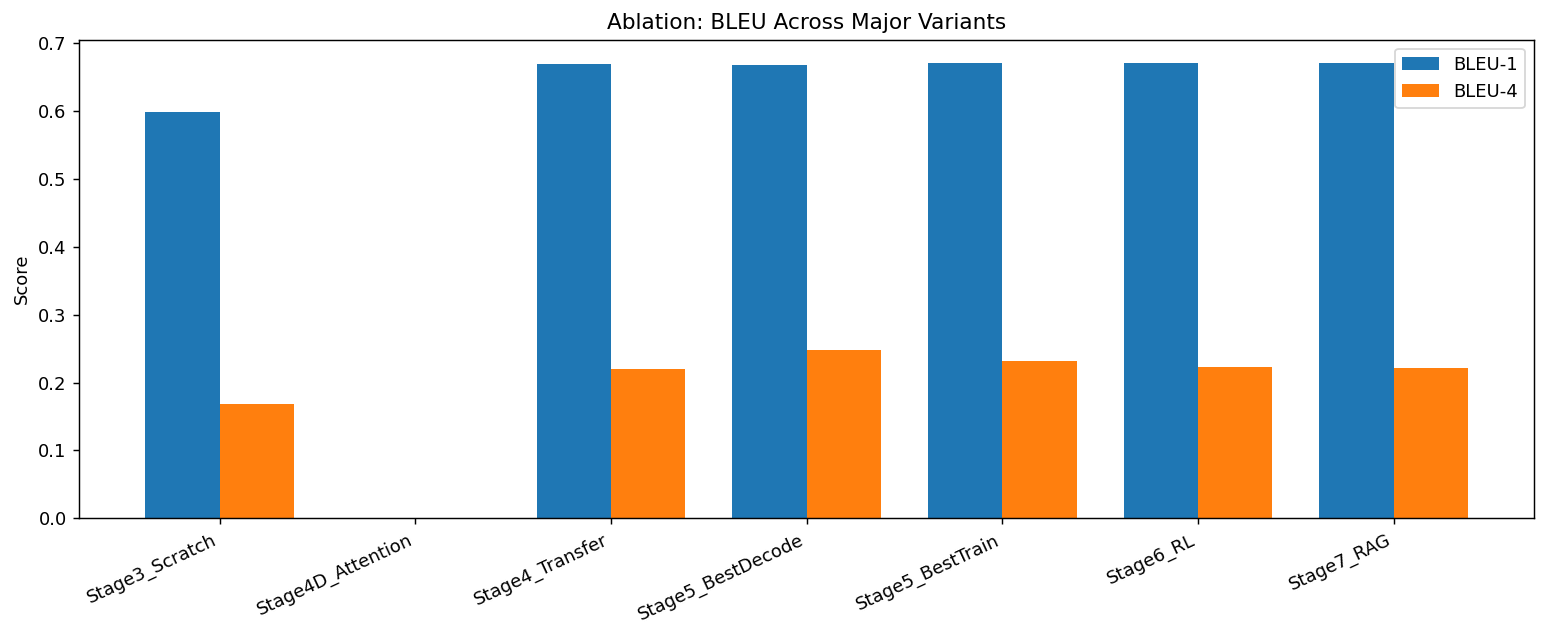

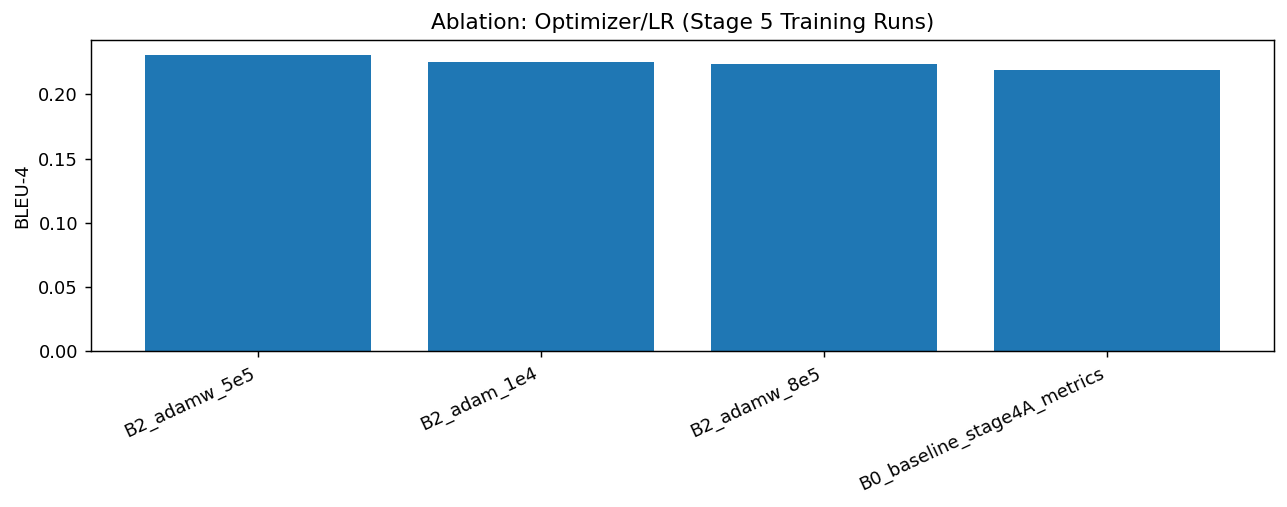

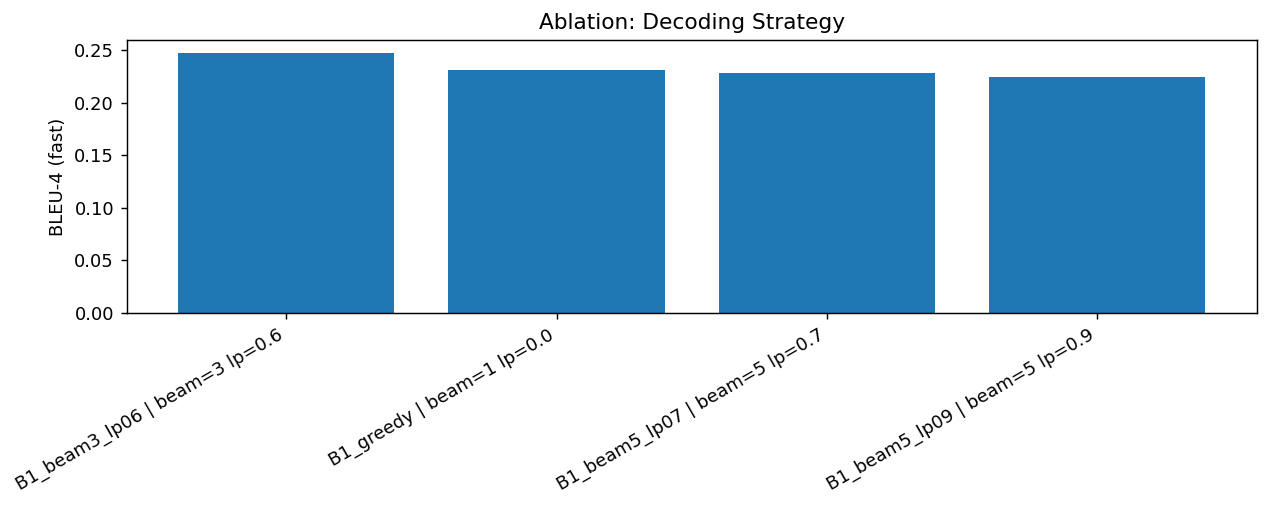

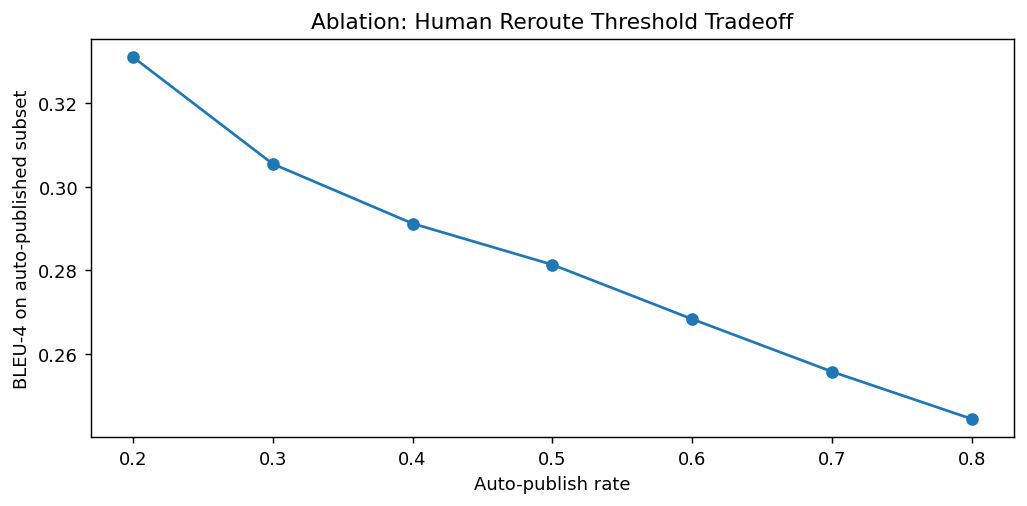

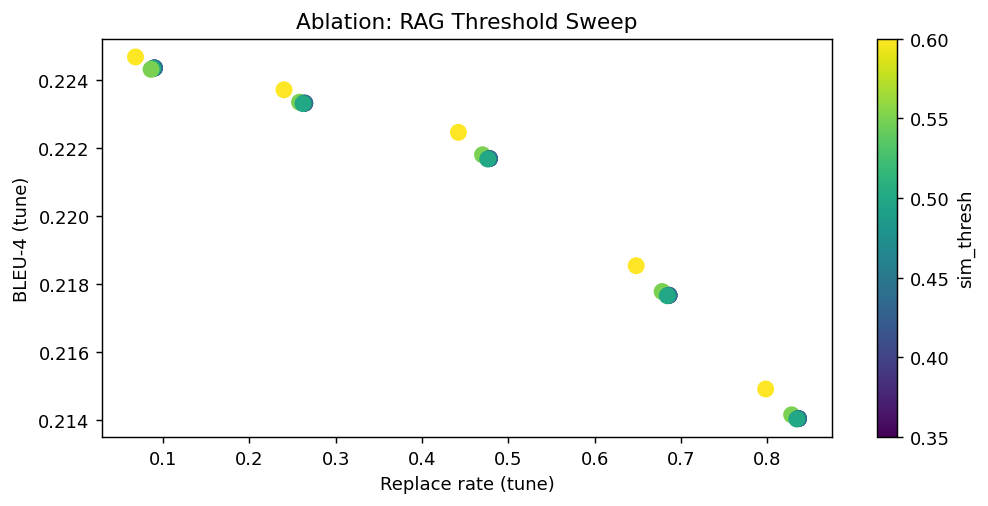

Saved all charts in: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/stage8_ablation/figures


In [12]:
# 1) Stage progression BLEU
p = ablation_df.copy()
p = p.sort_values("variant")
x = np.arange(len(p))
w = 0.38

plt.figure(figsize=(12, 5))
plt.bar(x - w/2, p["bleu1"].fillna(0), width=w, label="BLEU-1")
plt.bar(x + w/2, p["bleu4"].fillna(0), width=w, label="BLEU-4")
plt.xticks(x, p["variant"], rotation=25, ha="right")
plt.ylabel("Score")
plt.title("Ablation: BLEU Across Major Variants")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "chart_ablation_stage_bleu.png")
plt.show()

# 2) Train optimizer/LR ablation
t = train_ablation.copy()
plt.figure(figsize=(10, 4))
plt.bar(t["run_id"].astype(str), t["bleu4_rank"].astype(float))
plt.xticks(rotation=25, ha="right")
plt.ylabel("BLEU-4")
plt.title("Ablation: Optimizer/LR (Stage 5 Training Runs)")
plt.tight_layout()
plt.savefig(FIG / "chart_ablation_train_optimizer_bleu4.png")
plt.show()

# 3) Decode ablation
d = decode_ablation.copy()
labels = d["run_id"].astype(str) + " | beam=" + d["beam_size"].astype(str) + " lp=" + d["length_penalty"].astype(str)
plt.figure(figsize=(10, 4))
plt.bar(labels, d["bleu4_fast"].astype(float))
plt.xticks(rotation=30, ha="right")
plt.ylabel("BLEU-4 (fast)")
plt.title("Ablation: Decoding Strategy")
plt.tight_layout()
plt.savefig(FIG / "chart_ablation_decode_bleu4.png")
plt.show()

# 4) Reroute tradeoff
r = reroute_ablation.copy()
plt.figure(figsize=(8, 4))
plt.plot(r["auto_rate"], r["auto_bleu4"], marker="o")
plt.xlabel("Auto-publish rate")
plt.ylabel("BLEU-4 on auto-published subset")
plt.title("Ablation: Human Reroute Threshold Tradeoff")
plt.tight_layout()
plt.savefig(FIG / "chart_ablation_reroute_tradeoff.png")
plt.show()

# 5) RAG tuning
g = rag_ablation.copy()
plt.figure(figsize=(8, 4))
sc = plt.scatter(g["replace_rate_tune"], g["bleu4_tune"], c=g["sim_thresh"], s=70)
plt.xlabel("Replace rate (tune)")
plt.ylabel("BLEU-4 (tune)")
plt.title("Ablation: RAG Threshold Sweep")
cbar = plt.colorbar(sc)
cbar.set_label("sim_thresh")
plt.tight_layout()
plt.savefig(FIG / "chart_ablation_rag_sweep.png")
plt.show()

print("Saved all charts in:", FIG)


In [13]:
summary = f"""
# Stage 8 Ablation Summary

## 1) Architecture Ablation
- Stage 3 (scratch) BLEU-4: {m3.get("test_bleu4"):.4f}
- Stage 4 (transfer) BLEU-4: {m4.get("test_bleu4"):.4f}
- Stage 4D (attention) BLEU-4: {m4d.get("test_bleu4"):.4f}

## 2) Optimizer/LR Ablation (Stage 5 Training)
- Best run: {best_b2['run_id']}
- Optimizer: {best_b2.get('optimizer')}
- LR: {best_b2.get('lr')}
- BLEU-4 used for ranking: {float(best_b2['bleu4_rank']):.4f}

## 3) Decoding Ablation
- Best decode run: {best_decode['run_id']}
- Strategy: {best_decode['strategy']}
- Beam size: {best_decode['beam_size']}
- Length penalty: {best_decode['length_penalty']}
- BLEU-4 (fast): {float(best_decode['bleu4_fast']):.4f}

## 4) Human Reroute Ablation
- Best auto BLEU-4 threshold row:
  threshold={best_reroute_auto['threshold']:.4f}, auto_rate={best_reroute_auto['auto_rate']:.2f}, auto_bleu4={best_reroute_auto['auto_bleu4']:.4f}
- Near-50% operation row:
  threshold={reroute_50['threshold']:.4f}, auto_rate={reroute_50['auto_rate']:.2f}, auto_bleu4={reroute_50['auto_bleu4']:.4f}

## 5) RAG Ablation
- Best tune row:
  sim_thresh={best_rag_tune['sim_thresh']:.2f}, conf_thresh={best_rag_tune['conf_thresh']:.2f}, replace_rate={best_rag_tune['replace_rate_tune']:.4f}, bleu4_tune={best_rag_tune['bleu4_tune']:.4f}
- Full eval delta (RAG - base):
  delta_bleu4={full_rag.get('delta_bleu4'):.6f}, delta_bleu1={full_rag.get('delta_bleu1'):.6f}
"""

summary_path = ABL / "ablation_summary.md"
summary_path.write_text(summary.strip() + "\n", encoding="utf-8")
print("Saved:", summary_path)
print(summary[:1200])


Saved: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/stage8_ablation/ablation_summary.md

# Stage 8 Ablation Summary

## 1) Architecture Ablation
- Stage 3 (scratch) BLEU-4: 0.1685
- Stage 4 (transfer) BLEU-4: 0.2193
- Stage 4D (attention) BLEU-4: 0.0001

## 2) Optimizer/LR Ablation (Stage 5 Training)
- Best run: B2_adamw_5e5
- Optimizer: adamw
- LR: 5e-05
- BLEU-4 used for ranking: 0.2310

## 3) Decoding Ablation
- Best decode run: B1_beam3_lp06
- Strategy: beam
- Beam size: 3
- Length penalty: 0.6
- BLEU-4 (fast): 0.2473

## 4) Human Reroute Ablation
- Best auto BLEU-4 threshold row:
  threshold=0.5943, auto_rate=0.20, auto_bleu4=0.3310
- Near-50% operation row:
  threshold=0.5115, auto_rate=0.50, auto_bleu4=0.2814

## 5) RAG Ablation
- Best tune row:
  sim_thresh=0.60, conf_thresh=0.40, replace_rate=0.0680, bleu4_tune=0.2247
- Full eval delta (RAG - base):
  delta_bleu4=-0.000999, delta_bleu1=-0.000885



In [14]:
required = [
    TAB / "ablation_master_table.csv",
    TAB / "train_optimizer_ablation.csv",
    TAB / "decode_ablation.csv",
    TAB / "reroute_ablation.csv",
    TAB / "rag_tune_ablation.csv",
    FIG / "chart_ablation_stage_bleu.png",
    FIG / "chart_ablation_train_optimizer_bleu4.png",
    FIG / "chart_ablation_decode_bleu4.png",
    FIG / "chart_ablation_reroute_tradeoff.png",
    FIG / "chart_ablation_rag_sweep.png",
    ABL / "ablation_summary.md",
]

for p in required:
    assert p.exists(), f"Missing: {p}"

print("STAGE 8 ABLATION PASS")
print("Artifacts:", ABL)


STAGE 8 ABLATION PASS
Artifacts: /Users/dannyyy/Downloads/accessops_coco_ai/artifacts/stage8_ablation
